# Mushroom Classifier
This model's goal is to classify images of mushrooms and determine whether they are poisonous or safe.  
The model was trained with an AMD GPU, which caused a fair amount of issues and forced some architecture changes.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
import tensorflow as tf

# Verification block
print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# This will list your DirectML adapters (GPU:0 and GPU:1)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Detected: {gpus}")

C:\Users\Omistaja\anaconda3\envs\tf_directml\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Keras version: 2.10.0
TensorFlow version: 2.10.0
GPUs Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Performing data augmentation while the Jupyter server was running always crashed the kernel during training phase.  
To fix this, the entire dataset is augmented at once and saved as a new dataset.  
This means that the images are already augmented when loaded as a dataset.

In [2]:
from sklearn.model_selection import train_test_split

# Change Cell 3
data_dir = '../datasets/mushroom'
batch_size_n = 64
img_size = (224, 224)

# 1. Load Training Set (70%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=img_size,
    crop_to_aspect_ratio=True,
    shuffle=True,
    batch_size=None # Load as individual images for augmentation
)

# 2. Load the remaining 30% and split it into Val/Test
remaining_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=img_size,
    crop_to_aspect_ratio=True,
    batch_size=None
)

num_classes = 9
print(train_dataset.class_names)
print(remaining_dataset.class_names)
class_names = train_dataset.class_names

Found 6714 files belonging to 9 classes.
Using 4700 files for training.
Found 6714 files belonging to 9 classes.
Using 2014 files for validation.
['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']
['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']


The total dataset is now much larger than the original, because of the preprocessed images.

In [3]:
# Split the 30% into two 15% halves
dataset_size = 2014 
dataset_size = tf.data.experimental.cardinality(remaining_dataset).numpy()
print(dataset_size)
val_dataset = remaining_dataset.take(dataset_size // 2)
test_dataset = remaining_dataset.skip(dataset_size // 2)

2014


In [4]:
# Prefetch datasets to improve performance
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

#train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
#val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
#test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
def augment_fn(image, label):
    with tf.device('/CPU:0'):
        # Horizontal Flip
        image = tf.image.random_flip_left_right(image)
        
        # Subtle Zoom (90% to 100% of original size)
        zoom_factor = tf.random.uniform([], 0.9, 1.0)
        new_h = tf.cast(zoom_factor * 224, tf.int32)
        new_w = tf.cast(zoom_factor * 224, tf.int32)
        image = tf.image.random_crop(image, size=[new_h, new_w, 3])
        image = tf.image.resize(image, [224, 224])
        
        # Ensure standard range
        image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

# 1. Map augmentation to individual images
#train_dataset = train_dataset.map(
#    augment_fn, 
#    num_parallel_calls=tf.data.AUTOTUNE 
#)

# 2. Apply batching ONLY HERE
train_dataset = train_dataset.batch(batch_size_n).prefetch(2)
val_dataset = val_dataset.batch(batch_size_n).prefetch(2)
test_dataset = test_dataset.batch(batch_size_n).prefetch(2)

# 3. Add stability options
options = tf.data.Options()
options.experimental_deterministic = False 
train_dataset = train_dataset.with_options(options)

for images, labels in train_dataset.take(1):
    print(labels.numpy())

[4 3 7 3 2 6 7 5 4 6 7 3 2 1 3 7 8 6 4 1 5 6 2 2 5 3 7 2 6 2 2 2 2 2 6 6 7
 3 7 6 3 1 5 3 3 6 6 6 7 3 2 6 1 0 2 6 1 6 5 6 2 2 2 7]


In [6]:
from keras import Sequential
from keras import layers
from keras.optimizers import Adam

## CNN model (custom)
This model is a convolutional network that will be fully trained from the ground up on this dataset.

In [7]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255), 
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Flatten(), # This is vital for small detail recognition
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Lower dropout
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 186624)            0

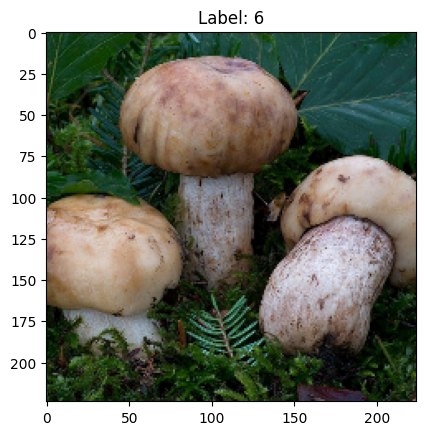

In [8]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


for images, labels in train_dataset.take(1):
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(f"Label: {labels[0]}")
    break

In [9]:
from keras.callbacks import EarlyStopping


for img, lbl in train_dataset.take(1):
    print(f"Batch Shape: {img.shape}") 
    print(f"Pixel Range: {np.min(img)} to {np.max(img)}")

from sklearn.utils.class_weight import compute_class_weight

# Assign weights to each class to balance file count discrepancies
labels = np.concatenate([y for x, y in train_dataset], axis=0)
class_weights = compute_class_weight(
     class_weight='balanced',
     classes=np.unique(labels),
     y=labels
 )
weight_dict = dict(enumerate(class_weights))    
print(weight_dict)

for images, labels in train_dataset.take(1):
    preds = model.predict(images)
    print(np.argmax(preds, axis=1)[:20])
    print(labels.numpy()[:20])

w_before = model.layers[0].get_weights()[0].copy()

small_train = train_dataset.take(1)

history = model.fit(
    small_train,
    epochs=50,
    validation_data=val_dataset,
    class_weight=weight_dict, # This is the magic line
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True)
    ]
)

w_after = model.layers[0].get_weights()[0]
print("has_trained", np.mean(w_after - w_before))
    
#history = model.fit(
#    train_dataset,
#    batch_size=batch_size_n,
#    epochs=1,
#    validation_data=val_dataset,
#    class_weight=weight_dict, # This is the magic line
#    callbacks=[
#        EarlyStopping(patience=10, restore_best_weights=True)
#    ]
#)
for images, labels in train_dataset.take(1):
    preds = model.predict(images)
    print(np.argmax(preds, axis=1)[:20])
    print(labels.numpy()[:20])

Batch Shape: (64, 224, 224, 3)
Pixel Range: 0.0 to 255.0
{0: 2.0641194554238034, 1: 0.9599673202614379, 2: 0.715372907153729, 3: 0.9034986543637062, 4: 2.088888888888889, 5: 2.3629964806435395, 6: 0.47561222424610405, 7: 0.6360806604411964, 8: 2.5474254742547426}
2/2 [==============================] - 0s 4ms/step
[8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8]
[7 1 5 6 3 1 7 6 1 6 3 8 7 7 6 3 1 5 1 5]


IndexError: list index out of range

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)
val_loss, val_acc = model.evaluate(val_dataset)
print("Test accuracy:", test_acc)
print("Validation accuracy:", val_acc)

The baseline for the current model is ~57%, with slight variations on each training run.  
Mushrooms are very complex structures, which means that this model needs to learn to sort through a lot of parameters.  
Pretrained models should be better at this task. The next cells compare the performance of EfficientNet and MobileNetV2.

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Mushroom Species')
plt.show()

In [ ]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras import Sequential
from keras import layers
from keras.optimizers import Adam

conv_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

conv_base.trainable = False

In [ ]:
from keras.optimizers import Adam
from keras.applications.mobilenet_v2 import preprocess_input

inputs = layers.Input(shape=(224, 224,3))
x = preprocess_input(inputs)
x = conv_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary()

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

mobilenet_history = model.fit(
    train_dataset,
    epochs=64,
    validation_data=val_dataset,
    callbacks=callbacks,
)

In [ ]:
acc = mobilenet_history.history["accuracy"]
val_acc = mobilenet_history.history["val_accuracy"]
loss = mobilenet_history.history["loss"]
val_loss = mobilenet_history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)
val_loss, val_acc = model.evaluate(val_dataset)
print("Test accuracy:", test_acc)
print("Validation accuracy:", val_acc)